In [2]:
# -*- coding: utf-8 -*-
"""
Framevib2D
----------

Driver for Vibration analysis of 2D Frame structure.

Created: June 2020

@author: Oscar Bondo Ellekvist, s163774


Input
-----
X  : Array (nnodes x 2)
     Node coordinates.
T  : Array (nel x 3), dtype = int
     Topology, [node1 node2 propno].
H  : Array (npropno x 4)
     Material properties, [E A I rho*A].
BC : Array (nc x 3)
     Constraint matrix, [node dof u].

"""

# Import packages
import numpy as np
import scipy as sp
import sys as sys

# Import functions
from kbeam import kbeam
from kbeamg import kbeamg
from mbeam import mbeam
from constidx import constidx
from ubeam import ubeam
from plotelem import plotelem
from plotelemdisp import plotelemdisp

# if "module 'scipy' has no attribute 'linalg'" then import as:
from scipy import linalg as linalg

### INPUT DATA

# Import input data
#from Examples.beam_simple import X,T,H,BC
#from Examples.beam_cantilever import X,T,H,BC
#from Examples.beam_clamped import X,T,H,BC
from Examples.frame_simple import X,T,H,BC

# Ensure correct dtype of input
BC = BC.astype(int)
T = T.astype(int)

### SYSTEM MATRICES

# Dimensions of FE model
dof  = 3
ndof = np.size(X,0)*dof

# Stiffness matrix
K = kbeam(T,X,H,dof)

# Mass matrix
M = mbeam(T,X,H,dof)

# Constrained (ic) and unconstrained (iu) dofs
(ic,iu) = constidx(BC,dof,ndof)

### VIBRATION ANALYSIS

# Generalized eigenvalue problem
(D,U) = linalg.eig(K[np.ix_(iu-1,iu-1)],M[np.ix_(iu-1,iu-1)])

# Natural frequencies from eigenvalues
omega = np.sqrt(D).real

# Sort frequencies and mode shapes
iw = np.argsort(omega)
omega = omega[iw]
freq  = omega/(2*np.pi)
U = U[:,iw]
print(freq[:5])


[ 0.85712156  3.62630746  7.95560468 10.22193028 13.21346497]


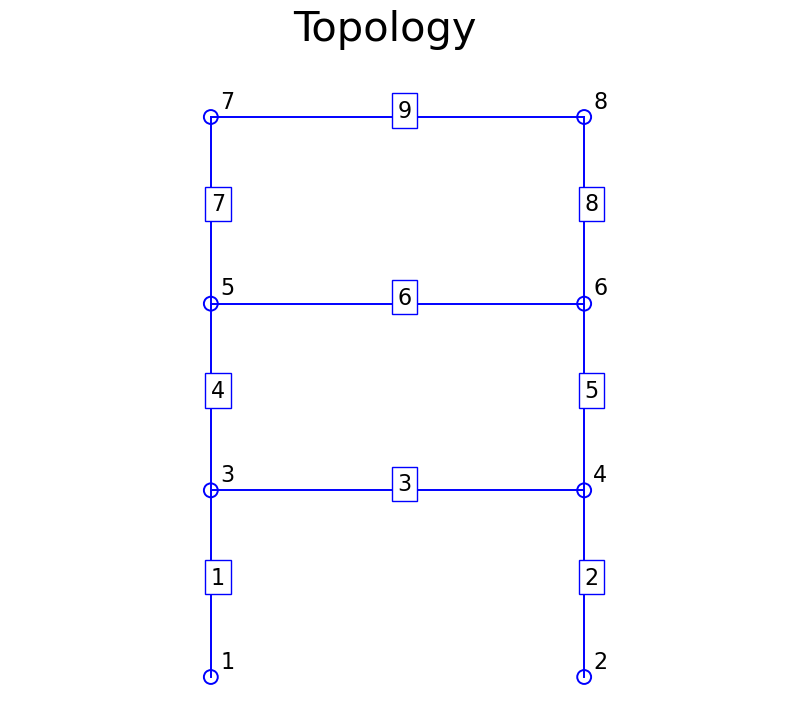

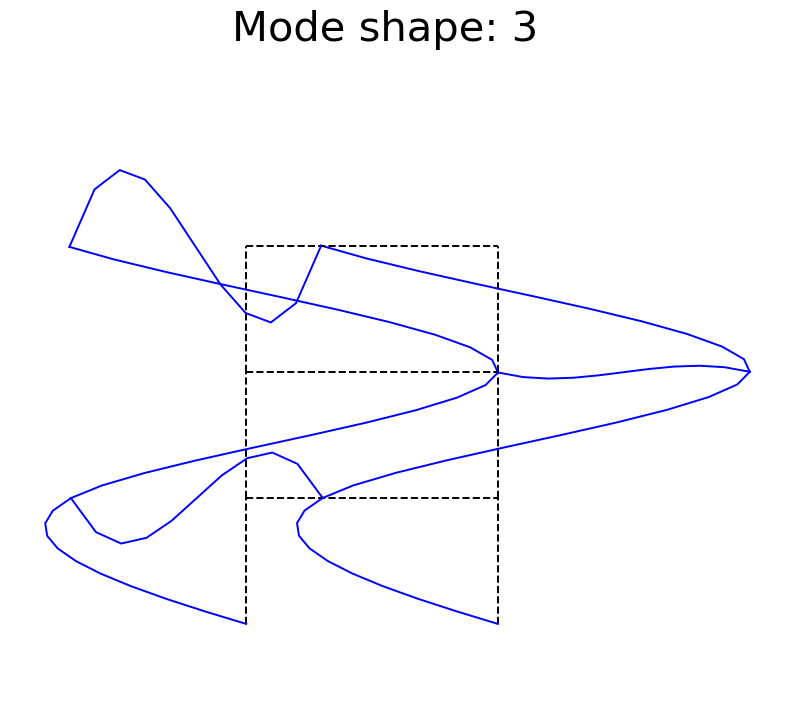

In [4]:

# Vibration mode to plot
mode = 3

# Mode shape vector normalized to unity
Vplot = np.zeros(ndof,dtype=float)
Vplot[iu-1] = U[:,mode-1]
Vplot = Vplot/np.max(np.abs((Vplot[np.arange(0,np.size(Vplot),3)],
                             Vplot[np.arange(1,np.size(Vplot),3)])))

# Vibration mode element displacements
Uvn = Vplot.reshape((np.size(X,0),dof))
Uve = ubeam(T,X,Uvn,11)

# Plot topology
plotelem(T,X,elnum=True,title='Topology')

# Plot deformed geometry
plotfac = 10 # amplification plot factor
plotelemdisp(T[:,0:3],X,plotfac*Uve,title=('Mode shape: '+str(mode)))

# stop code here - move up to break code where you like
# sys.exit()